In [1]:
!pip install catboost


In [7]:
import pandas as pd  
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor

In [10]:
!pip uninstall catboost -y
!pip uninstall numpy -y


Found existing installation: catboost 1.2.8
Uninstalling catboost-1.2.8:


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\nani\anaconda3\lib\site-packages\pip\_internal\cli\base_command.py", line 228, in _main
    status = self.run(options, args)
  File "C:\Users\nani\anaconda3\lib\site-packages\pip\_internal\commands\uninstall.py", line 93, in run
    uninstall_pathset.commit()
  File "C:\Users\nani\anaconda3\lib\site-packages\pip\_internal\req\req_uninstall.py", line 450, in commit
    self._moved_paths.commit()
  File "C:\Users\nani\anaconda3\lib\site-packages\pip\_internal\req\req_uninstall.py", line 290, in commit
    save_dir.cleanup()
  File "C:\Users\nani\anaconda3\lib\site-packages\pip\_internal\utils\temp_dir.py", line 199, in cleanup
    rmtree(ensure_text(self._path))
  File "C:\Users\nani\anaconda3\lib\site-packages\pip\_vendor\retrying.py", line 49, in wrapped_f
    return Retrying(*dargs, **dkw).call(f, *args, **kw)
  File "C:\Users\nani\anaconda3\lib\site-packages\pip\_vendor\retrying.py", line 212, in call
    raise att

  Successfully uninstalled catboost-1.2.8
Found existing installation: numpy 1.19.2
Uninstalling numpy-1.19.2:
  Successfully uninstalled numpy-1.19.2


In [12]:
!pip install numpy==1.23.5
!pip install catboost


  Using cached catboost-1.2.8-cp38-cp38-win_amd64.whl (102.5 MB)


In [15]:
from catboost import CatBoostRegressor

ValueError: numpy.ndarray size changed, may indicate binary incompatibility. Expected 96 from C header, got 80 from PyObject

In [17]:
df = pd.read_csv("data\\stud.csv")

In [18]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [19]:
x = df

In [23]:
x = df.drop(columns=['math_score'],axis=1)

In [24]:
y = df['math_score']

In [25]:
num_feature = x.select_dtypes(exclude="object").columns
cat_feature = x.select_dtypes(include="object").columns

In [26]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer


In [27]:
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer([
    ("OneHotEncoder" ,oh_transformer,cat_feature),
    ("StandardScaler",numeric_transformer,num_feature),
]
)

In [28]:
x = preprocessor.fit_transform(x)

In [29]:
x

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [30]:
x.shape

(1000, 19)

In [31]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [32]:
x_train.shape

(800, 19)

In [50]:
def evealution_model(true,predicted):
    mea = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rsme = np.sqrt(mean_squared_error(true,predicted))
    r2_scoreed = r2_score(true,predicted)
    return mea,r2_scoreed,rsme

In [65]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge

models ={
    "LinearRegression": LinearRegression(),
    "LogisticRegression" :LogisticRegression(),
    "lasoo": Lasso(),
    "ridge":Ridge(),
    "K- Neighbors Regression":KNeighborsRegressor(),
    "DecisionTree Regressor": DecisionTreeRegressor(),
    "RandomForest Regressor":RandomForestRegressor(),
    "XGB Regressor":XGBRegressor()
}
model_list = []
r2_list = []



In [66]:
model_list = []
r2_list = []

for model_name, model in models.items():

    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    model_train_mae, model_train_rmse, model_train_r2 = evealution_model(
        y_train, y_train_pred
    )
    model_test_mae, model_test_rmse, model_test_r2 = evealution_model(
        y_test, y_test_pred
    )

    print(model_name)
    model_list.append(model_name)

    print("Model performance for Training set")
    print("- RMSE: {:.4f}".format(model_train_rmse))
    print("- MAE: {:.4f}".format(model_train_mae))
    print("- R2 score: {:.4f}".format(model_train_r2))

    print("===================================")

    print("Model performance for Test set")
    print("- RMSE: {:.4f}".format(model_test_rmse))
    print("- MAE: {:.4f}".format(model_test_mae))
    print("- R2 score: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

    print("===================================\n")


LinearRegression
Model performance for Training set
- RMSE: 0.8743
- MAE: 4.2667
- R2 score: 5.3231
Model performance for Test set
- RMSE: 0.8804
- MAE: 4.2148
- R2 score: 5.3940

LogisticRegression
Model performance for Training set
- RMSE: 0.7137
- MAE: 5.7900
- R2 score: 8.0338
Model performance for Test set
- RMSE: 0.6563
- MAE: 7.2800
- R2 score: 9.1449

lasoo
Model performance for Training set
- RMSE: 0.8071
- MAE: 5.2063
- R2 score: 6.5938
Model performance for Test set
- RMSE: 0.8253
- MAE: 5.1579
- R2 score: 6.5197

ridge
Model performance for Training set
- RMSE: 0.8743
- MAE: 4.2650
- R2 score: 5.3233
Model performance for Test set
- RMSE: 0.8806
- MAE: 4.2111
- R2 score: 5.3904

K- Neighbors Regression
Model performance for Training set
- RMSE: 0.8559
- MAE: 4.5038
- R2 score: 5.6989
Model performance for Test set
- RMSE: 0.7839
- MAE: 5.6360
- R2 score: 7.2520

DecisionTree Regressor
Model performance for Training set
- RMSE: 0.9997
- MAE: 0.0187
- R2 score: 0.2795
Model p

In [67]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['model name','r2_score']).sort_values(by=['r2_score'],ascending=False)

,model name,r2_score
1,LogisticRegression,9.144944
5,DecisionTree Regressor,8.171291
4,K- Neighbors Regression,7.251979
7,XGB Regressor,6.588941
2,lasoo,6.519695
6,RandomForest Regressor,5.988523
0,LinearRegression,5.393994
3,ridge,5.390387


In [73]:
lin_model = LinearRegression(fit_intercept= True)
lin_model = lin_model.fit(x_train,y_train)
y_pred = lin_model.predict(x_test)
score =r2_score(y_test,y_pred)*100
print("acc_score: {%.2f}"%score)

acc_score: {88.04}


c:\Users\nani\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='math_score'>

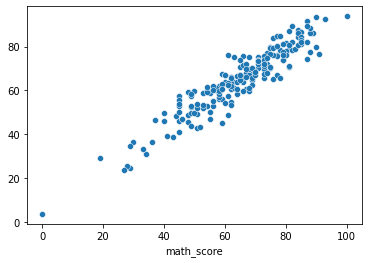

In [75]:

import seaborn as sns 
sns.scatterplot(y_test,y_pred)